# Lab - EDA Bivariate Analysis: Diving into Amazon UK Product Insights Part II

**Objective**: Delve into the dynamics of product pricing on Amazon UK to uncover insights that can inform business strategies and decision-making.

**Dataset**: [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/) — 2,443,651 listings, downloaded locally to `data/amz_uk_price_prediction_dataset.csv` (not committed, ~480MB, over GitHub's file size limit).

**Note on the dataset**: the actual columns are `uid, asin, title, stars, reviews, price, isBestSeller, boughtInLastMonth, category` — there is no `brand` column in this version of the dataset, so the "brands" angle mentioned in the lab title isn't explorable here; the analysis below covers category, price, best-seller status, and ratings instead.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

%matplotlib inline

In [2]:
df = pd.read_csv("data/amz_uk_price_prediction_dataset.csv")
print(df.shape)
df.head()

(2443651, 9)


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


No missing values and no duplicates in this dataset (checked once, not repeated below to keep this notebook focused on the bivariate analysis).

In [3]:
assert df.isnull().sum().sum() == 0
assert df.duplicated().sum() == 0
print(f"{df['category'].nunique()} categories, {df['isBestSeller'].sum()} best-sellers out of {len(df):,} listings ({100*df['isBestSeller'].mean():.2f}%)")

296 categories, 7980 best-sellers out of 2,443,651 listings (0.33%)


---
## Part 1: Analyzing Best-Seller Trends Across Product Categories

### 1. Crosstab analysis

In [4]:
ct = pd.crosstab(df['category'], df['isBestSeller'])

# proportion of best-sellers within each category, sorted descending
bestseller_share = ct[True] / ct.sum(axis=1)
bestseller_share = bestseller_share.sort_values(ascending=False)
bestseller_share.head(15)

category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057686
Mobile Phone Accessories          0.042471
Power & Hand Tools                0.035339
Billiard, Snooker & Pool          0.032129
Pet Supplies                      0.030200
Home Brewing & Wine Making        0.028455
Wind Instruments                  0.028000
Mirrors                           0.028000
Professional Medical Supplies     0.027344
PC & Video Games                  0.025466
Bakeware                          0.025105
Material Handling Products        0.025000
Bedding Accessories               0.024390
dtype: float64

**Yes** — being a best-seller is far from evenly distributed across categories. The top categories (Grocery, Smart Home Security & Lighting, Health & Personal Care — all around 5.7-5.8%) have roughly 15x the best-seller rate of a category sitting at the ~0.4% dataset average, and a large number of categories have exactly 0% best-sellers.

### 2. Statistical tests

In [5]:
chi2, p_value, dof, expected = chi2_contingency(ct)

n = ct.sum().sum()
min_dim = min(ct.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"Chi-square statistic: {chi2:,.1f}")
print(f"p-value: {p_value:.3e}")
print(f"degrees of freedom: {dof}")
print(f"Cramer's V: {cramers_v:.4f}")

Chi-square statistic: 36,540.2
p-value: 0.000e+00
degrees of freedom: 295
Cramer's V: 0.1223


The chi-square test rejects independence overwhelmingly (p ≈ 0, with a sample this large almost any real difference will be "significant"). But **Cramér's V ≈ 0.12** tells the more useful story: the *practical* strength of the category → best-seller association is weak. Category shifts the odds of being a best-seller, but it's a small effect next to whatever else drives that label — statistically real, not a strong lever on its own.

### 3. Visualizations

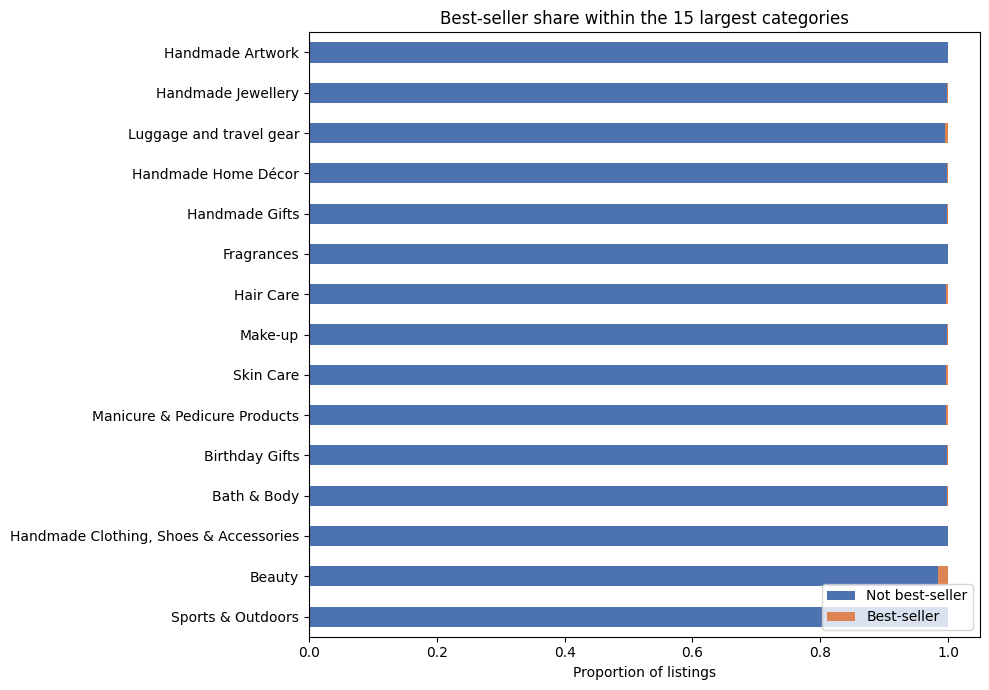

In [6]:
# Top 15 categories by listing count, so the chart stays readable
# (296 categories total, most with only a handful of listings)
top15_categories = df['category'].value_counts().head(15).index
ct_top15 = pd.crosstab(df[df['category'].isin(top15_categories)]['category'], df[df['category'].isin(top15_categories)]['isBestSeller'])
ct_top15_norm = ct_top15.div(ct_top15.sum(axis=1), axis=0).loc[top15_categories]

fig, ax = plt.subplots(figsize=(10, 7))
ct_top15_norm.plot(kind='barh', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_xlabel('Proportion of listings')
ax.set_ylabel('')
ax.set_title('Best-seller share within the 15 largest categories')
ax.legend(['Not best-seller', 'Best-seller'], loc='lower right')
plt.tight_layout()
plt.show()

Even among the largest categories, the best-seller slice is thin everywhere — consistent with the weak Cramér's V above. `Sports & Outdoors` alone accounts for a third of the whole dataset (836K of 2.44M listings), which is worth keeping in mind for every category-level comparison in this notebook: it's an outlier in volume, not just one category among many.

---
## Part 2: Exploring Product Prices and Ratings Across Categories

### 0. Removing price outliers (IQR method)

In [7]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Rows before: {len(df):,}, after: {len(df_no_outliers):,} ({len(df) - len(df_no_outliers):,} removed, {100*(1 - len(df_no_outliers)/len(df)):.1f}%)")

IQR bounds: [-44.01, 99.99]
Rows before: 2,443,651, after: 2,115,963 (327,688 removed, 13.4%)


### 1. Violin plots

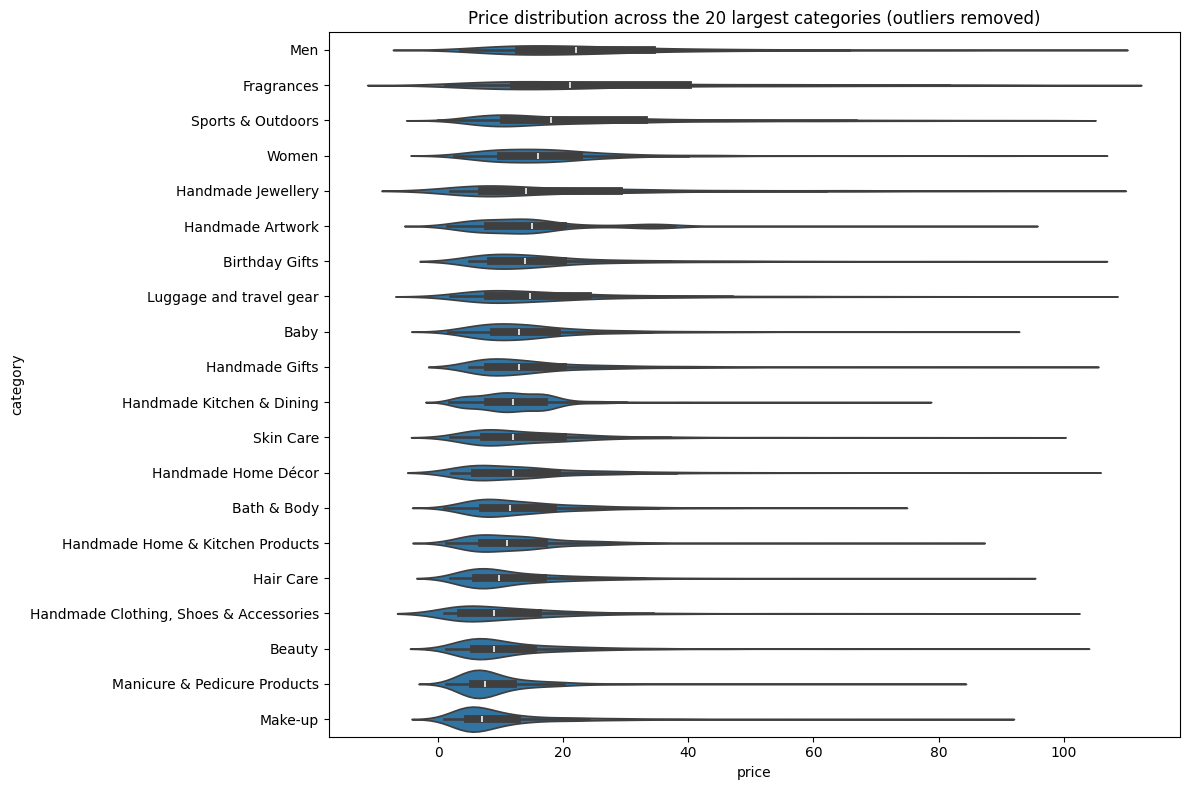

In [8]:
top20_by_count = df_no_outliers['category'].value_counts().head(20).index
violin_data = df_no_outliers[df_no_outliers['category'].isin(top20_by_count)]

# Sampled for rendering speed -- the full top-20 slice is still well over a
# million rows, and a violin plot's shape converges long before that.
violin_sample = violin_data.sample(n=min(50_000, len(violin_data)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 8))
order = violin_data.groupby('category')['price'].median().sort_values(ascending=False).index
sns.violinplot(data=violin_sample, y='category', x='price', order=order, ax=ax)
ax.set_title('Price distribution across the 20 largest categories (outliers removed)')
plt.tight_layout()
plt.show()

In [9]:
# Highest median price -- across ALL categories, not just the top 20 by count
median_price_by_category = df_no_outliers.groupby('category')['price'].median().sort_values(ascending=False)
median_price_by_category.head(10)

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

**`Desktop PCs`** has the highest median price (£74.00) across all categories — followed closely by `Boxing Shoes`, `Tablets`, `Graphics Cards`, and `Motherboards`. The tech-hardware cluster (PCs, tablets, graphics cards, motherboards) dominating the top of this list makes intuitive sense; `Boxing Shoes` sitting right in the middle of that cluster is the one genuine surprise.

### 2. Bar charts

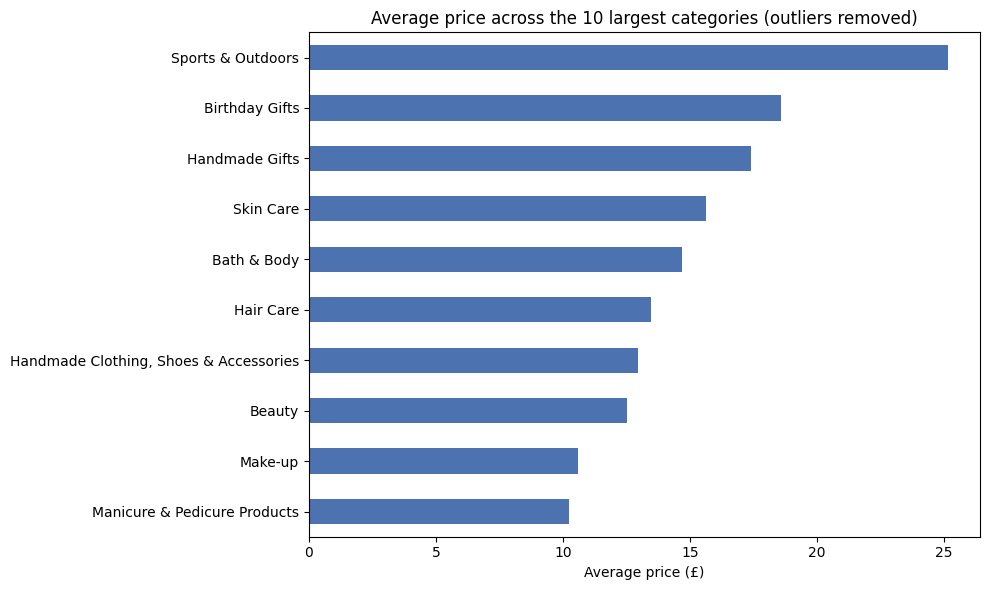

In [10]:
top10_by_count = df_no_outliers['category'].value_counts().head(10).index
avg_price_top10 = df_no_outliers[df_no_outliers['category'].isin(top10_by_count)].groupby('category')['price'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
avg_price_top10.plot(kind='barh', ax=ax, color='#4C72B0')
ax.invert_yaxis()
ax.set_xlabel('Average price (£)')
ax.set_ylabel('')
ax.set_title('Average price across the 10 largest categories (outliers removed)')
plt.tight_layout()
plt.show()

In [11]:
# Highest average price -- across ALL categories, not just the top 10 by count
avg_price_by_category = df_no_outliers.groupby('category')['price'].mean().sort_values(ascending=False)
avg_price_by_category.head(10)

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64

**`Motherboards`** commands the highest average price (£68.77) overall — the same tech-hardware cluster as the median-price ranking, just reordered slightly (mean vs. median react differently to the shape of each category's remaining right-tail after outlier removal).

### 3. Box plots

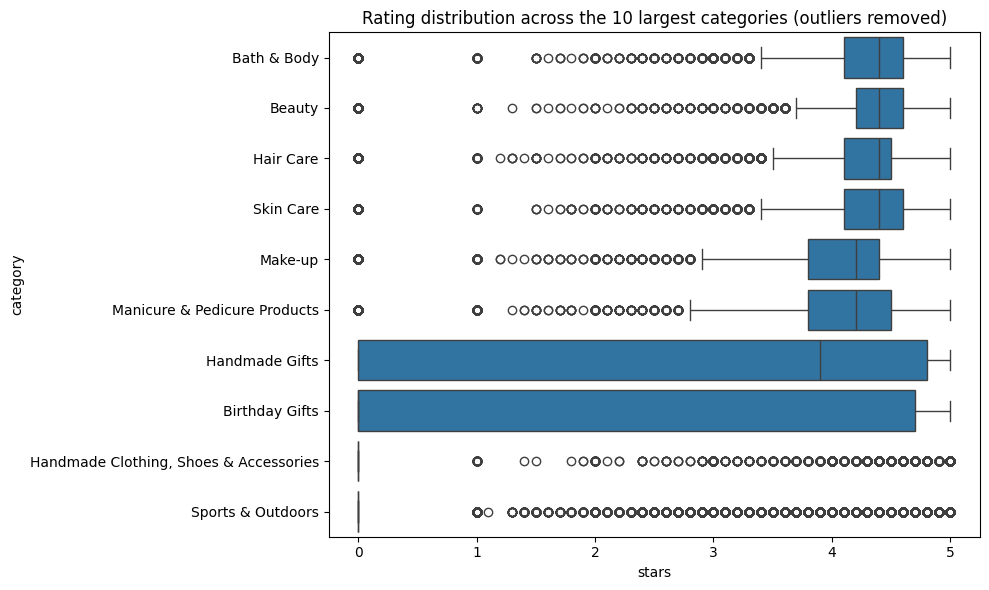

In [12]:
ratings_data = df_no_outliers[df_no_outliers['category'].isin(top10_by_count)]
order_ratings = ratings_data.groupby('category')['stars'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=ratings_data, y='category', x='stars', order=order_ratings, ax=ax)
ax.set_title('Rating distribution across the 10 largest categories (outliers removed)')
plt.tight_layout()
plt.show()

In [13]:
# Highest median rating -- across ALL categories, not just the top 10 by count
median_rating_by_category = df_no_outliers.groupby('category')['stars'].median().sort_values(ascending=False)
median_rating_by_category.head(10)

category
Computer Memory                 4.7
Building & Construction Toys    4.6
Office Paper Products           4.6
Luxury Food & Drink             4.6
Kids' Play Figures              4.6
Hobbies                         4.6
Beer, Wine & Spirits            4.6
Laptop Accessories              4.6
Cables & Accessories            4.5
CPUs                            4.5
Name: stars, dtype: float64

**`Computer Memory`** has the highest median rating (4.7) across all categories. One data quality flag worth naming here: several of the *largest* categories (`Sports & Outdoors`, `Birthday Gifts`, `Handmade Clothing, Shoes & Accessories`) show a **median rating of 0.0** in the box plot above — that's almost certainly `stars = 0` being used as a "no ratings yet" placeholder rather than a genuine 0-star average, not something to read as "customers hate these products."

---
## Part 3: Investigating the Interplay Between Product Prices and Ratings

### 1. Correlation coefficient

In [14]:
price_stars_corr = df_no_outliers['price'].corr(df_no_outliers['stars'])
print(f"Pearson correlation (price, stars): {price_stars_corr:.4f}")

Pearson correlation (price, stars): -0.0777


**No** — at -0.078, price and rating are essentially uncorrelated (technically significant with 2M+ rows, but far too weak to act on). Paying more doesn't reliably buy a better rating on Amazon UK, at least not linearly and not once the placeholder-zero ratings noted above are still sitting in the data.

### 2. Visualizations

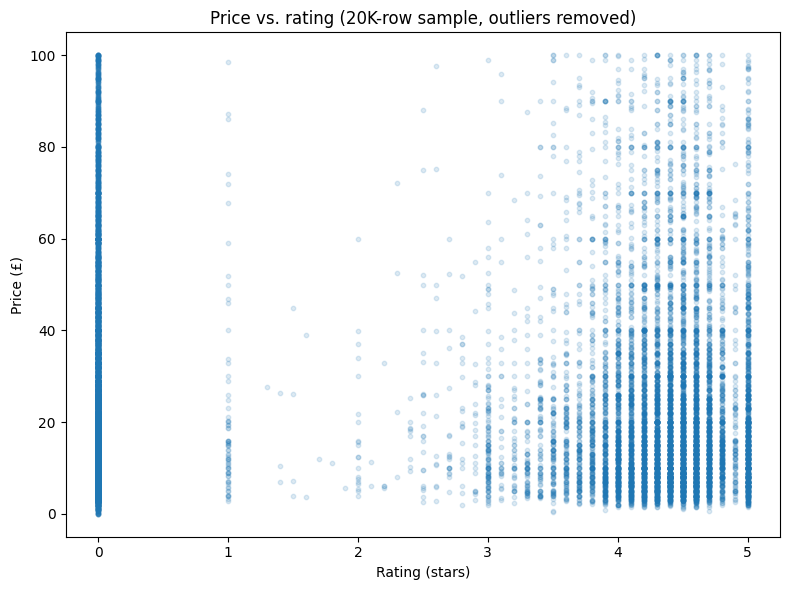

In [15]:
# Sampled for a readable scatter -- 2M+ overplotted points show nothing a
# 20K sample doesn't already show, just slower to render.
scatter_sample = df_no_outliers.sample(n=20_000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(scatter_sample['stars'], scatter_sample['price'], alpha=0.15, s=10)
ax.set_xlabel('Rating (stars)')
ax.set_ylabel('Price (£)')
ax.set_title('Price vs. rating (20K-row sample, outliers removed)')
plt.tight_layout()
plt.show()

No clear trend line, just a dense cloud — consistent with the near-zero correlation. The one visible pattern is the vertical stripe at `stars = 0`, the placeholder-rating products spanning the full price range.

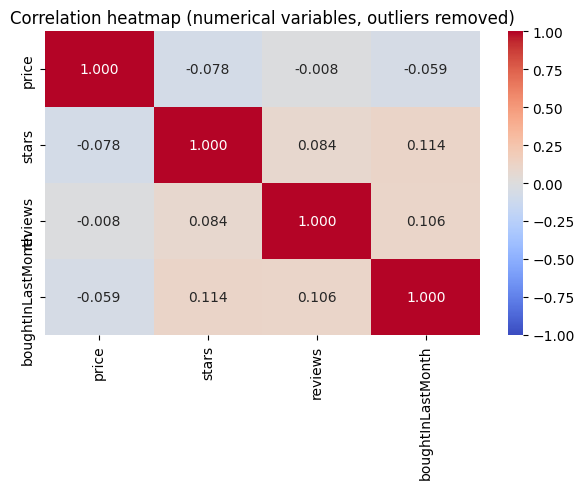

In [16]:
numerical_cols = ['price', 'stars', 'reviews', 'boughtInLastMonth']
corr_matrix = df_no_outliers[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation heatmap (numerical variables, outliers removed)')
plt.tight_layout()
plt.show()

Every pairwise correlation among these four numerical variables is weak (all under 0.12 in magnitude). `reviews` and `boughtInLastMonth` have the strongest relationship of the bunch (0.106) — mildly reassuring, since more reviews plausibly tracks more purchases — but nothing here is strong enough to lean on for prediction.

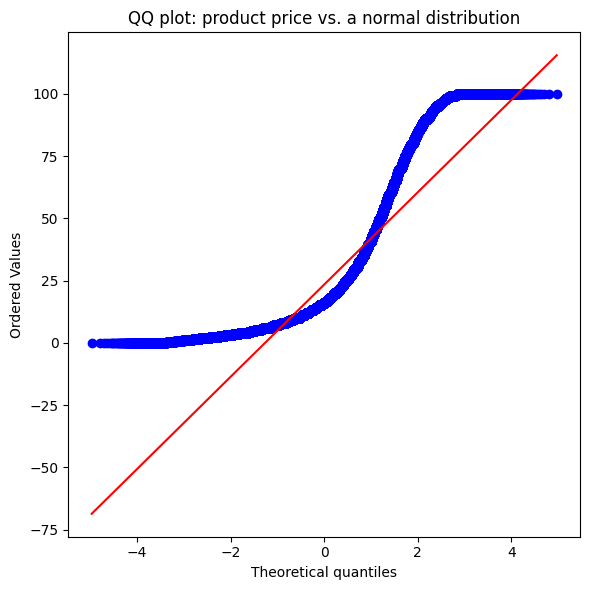

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(df_no_outliers['price'], dist='norm', plot=ax)
ax.set_title('QQ plot: product price vs. a normal distribution')
plt.tight_layout()
plt.show()

Price does **not** follow a normal distribution, even with outliers already removed — the points curve away from the reference line at both ends, especially the right tail, showing the distribution is still right-skewed. That's typical for price data (bounded at £0, no equivalent upper bound), and it's the same reason a t-test on raw prices (rather than log-prices or a rank-based test) needs some caution.

---
## Bonus: same Part 3 analysis, keeping the outliers

In [18]:
price_stars_corr_with_outliers = df['price'].corr(df['stars'])
print(f"Pearson correlation (price, stars), WITH outliers: {price_stars_corr_with_outliers:.4f}")
print(f"Pearson correlation (price, stars), without outliers: {price_stars_corr:.4f}")

Pearson correlation (price, stars), WITH outliers: -0.1249
Pearson correlation (price, stars), without outliers: -0.0777


Keeping the outliers actually *strengthens* the negative correlation (-0.125 vs. -0.078) — the small number of very expensive products pull the relationship further negative. It's still a weak correlation either way, but the direction is consistent: if anything, the priciest outlier products skew slightly *lower*-rated, not higher. That's a useful sanity check that removing outliers in Part 3 didn't manufacture the "no real correlation" finding — if anything, outliers were making price and rating look *more* related than they are for the typical product.